# Olist 巴西电商订单经营分析（Python 注释版）

## 项目目标
基于 Olist 巴西电商公开数据，使用 Python 完成订单与客户数据清洗、多表关联、GMV 与区域表现分析、月度趋势分析及 RFM 客户分层。

## 数据说明
- 订单表：订单状态、下单时间、签收时间等。
- 客户表：客户唯一标识与所在州。
- 订单明细表：商品价格与运费，用于计算订单 GMV。

> 注意：本 Notebook 仅分析已签收（`delivered`）订单；GMV 定义为商品金额与运费金额之和。


## 1. 环境配置与数据读取
导入分析与可视化库，读取三张核心业务表，并先确认数据规模。


In [1]:
# 导入路径、数据处理与可视化工具
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一图表风格；便于后续图表保持一致
sns.set_theme(style="whitegrid")
# Notebook 中完整显示列，便于检查字段
pd.set_option("display.max_columns", None)

# 原始 CSV 文件所在目录（相对 Notebook 当前目录）
data_dir = Path("archive (3)")

# 读取两张核心表：订单表记录订单生命周期，客户表提供区域属性
orders = pd.read_csv(data_dir / "olist_orders_dataset.csv")
customers = pd.read_csv(data_dir / "olist_customers_dataset.csv")

# 先核对行列数，再抽样查看字段和数据格式
print("订单表：", orders.shape)
print("客户表：", customers.shape)

display(orders.head())
display(customers.head())


订单表： (99441, 8)
客户表： (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## 2. 时间字段清洗与数据质量检查
将文本时间转换为 `datetime`；缺失的物流时间通常与未完成订单相关，因此保留缺失值而不进行填补。


In [2]:
# 需要转换的订单时间字段
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

# 将文本转换为 pandas datetime；无法解析的值转为 NaT，避免程序报错
orders[date_cols] = orders[date_cols].apply(
    pd.to_datetime,
    errors="coerce",
)

# 缺失的发货/签收时间通常来自取消或未完成订单，不应填 0 或随意填充
print("订单表缺失值：")
display(orders.isna().sum().sort_values(ascending=False))

# 检查不同订单状态的数量，为后续筛选 delivered 订单提供依据
print("订单状态分布：")
display(orders["order_status"].value_counts())


订单表缺失值：


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

订单状态分布：


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## 3. 区域订单表现：订单表与客户表关联
筛选已签收订单后，根据 `customer_id` 关联客户州信息。`validate='one_to_one'` 用于验证连接关系，防止意外的重复匹配。


In [3]:
# 仅保留已经签收的订单，避免未完成订单影响 GMV 与履约分析
delivered_orders = orders.loc[
    orders["order_status"].eq("delivered")
].copy()

# 按 customer_id 关联州信息；一张订单对应一位收货客户
order_customer = delivered_orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="inner",
    validate="one_to_one",  # 验证键关系，防止重复连接
)

# 按州统计已签收订单量，并从高到低排序
state_orders = (
    order_customer
    .groupby("customer_state", as_index=False)
    .agg(delivered_orders=("order_id", "nunique"))
    .sort_values("delivered_orders", ascending=False)
)

print("已签收订单数：", len(delivered_orders))
display(state_orders.head(10))


已签收订单数： 96478


,customer_state,delivered_orders
25,SP,40501
18,RJ,12350
10,MG,11354
22,RS,5345
17,PR,4923
23,SC,3546
4,BA,3256
6,DF,2080
7,ES,1995
8,GO,1957


## 4. GMV 计算：先聚合，再关联
订单明细表一张订单可能对应多行商品。先按 `order_id` 聚合到订单粒度，再关联订单表，避免多表连接后重复累计金额。


In [4]:
# 订单明细表包含商品价格和运费，一张订单可能有多个商品明细
order_items = pd.read_csv(
    data_dir / "olist_order_items_dataset.csv"
)

# 先按 order_id 汇总到订单粒度，避免后续连接时将订单金额重复累计
order_gmv = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        product_amount=("price", "sum"),
        freight_amount=("freight_value", "sum"),
    )
)

# 本项目 GMV 口径：商品金额 + 运费金额
order_gmv["total_amount"] = (
    order_gmv["product_amount"]
    + order_gmv["freight_amount"]
)

# 已签收订单依次关联客户州和订单 GMV，再按州汇总
state_gmv = (
    delivered_orders
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        order_gmv,
        on="order_id",
        how="inner",
        validate="one_to_one",
    )
    .groupby("customer_state", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        total_gmv=("total_amount", "sum"),
    )
    .sort_values("total_gmv", ascending=False)
)

# 计算州维度客单价
state_gmv["avg_order_amount"] = (
    state_gmv["total_gmv"]
    / state_gmv["delivered_orders"]
).round(2)

display(state_gmv.head(10))


,customer_state,delivered_orders,total_gmv,avg_order_amount
25,SP,40501,5769703.15,142.46
18,RJ,12350,2055401.57,166.43
10,MG,11354,1818891.67,160.20
22,RS,5345,861472.79,161.17
17,PR,4923,781708.80,158.79
23,SC,3546,595127.78,167.83
4,BA,3256,591137.81,181.55
6,DF,2080,346123.35,166.41
8,GO,1957,334212.35,170.78
7,ES,1995,317657.93,159.23


## 5. 各州 GMV Top10 可视化
用横向条形图展示 GMV 前十州；对数据升序排列后绘图，使最大值显示在最上方。


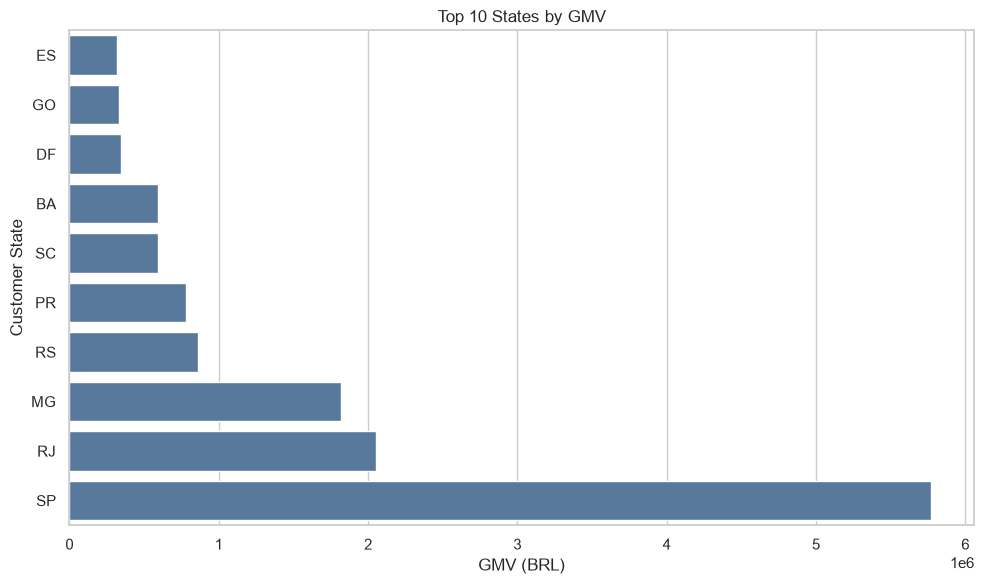

In [5]:
# 提取 GMV 前十州；升序排列使最大条形位于图表上方
top10_states = (
    state_gmv
    .head(10)
    .sort_values("total_gmv", ascending=True)
)

# 所有导出图表统一保存至 output 文件夹
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_states,
    x="total_gmv",
    y="customer_state",
    color="#4C78A8",
)

plt.title("Top 10 States by GMV")
plt.xlabel("GMV (BRL)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.savefig(
    output_dir / "state_gmv_top10.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


## 6. 月度 GMV 与订单量趋势
按下单月份汇总 GMV 和已签收订单量，并使用双坐标轴展示销售额与订单规模的同步变化。日期横轴的柱宽设置为 20 天，避免月度柱形显示为细线。


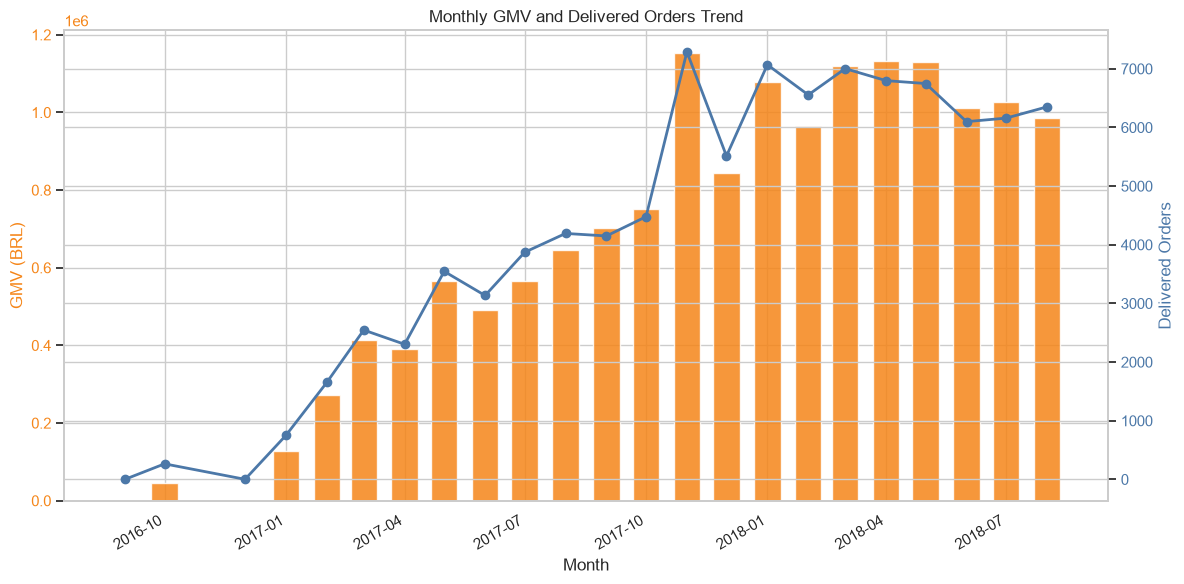

In [7]:
# 在订单粒度上按购买月份汇总 GMV 与订单量
monthly_gmv = (
    delivered_orders
    .merge(
        order_gmv,
        on="order_id",
        how="inner",
        validate="one_to_one",
    )
    .assign(
        # 将具体日期归并为每月 1 日，便于按月分组
        purchase_month=lambda df: (
            df["order_purchase_timestamp"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )
    )
    .groupby("purchase_month", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        gmv=("total_amount", "sum"),
    )
)

# 左轴用柱形展示 GMV，右轴用折线展示订单量
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    monthly_gmv["purchase_month"],
    monthly_gmv["gmv"],
    width=20,  # 月度日期横轴需扩大柱宽，否则柱形会显示为细线
    color="#F58518",
    alpha=0.85,
    label="GMV",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("GMV (BRL)", color="#F58518")
ax1.tick_params(axis="y", labelcolor="#F58518")

ax2 = ax1.twinx()
ax2.plot(
    monthly_gmv["purchase_month"],
    monthly_gmv["delivered_orders"],
    color="#4C78A8",
    marker="o",
    linewidth=2,
    label="Delivered Orders",
)
ax2.set_ylabel("Delivered Orders", color="#4C78A8")
ax2.tick_params(axis="y", labelcolor="#4C78A8")

plt.title("Monthly GMV and Delivered Orders Trend")
fig.autofmt_xdate()
plt.tight_layout()

plt.savefig(
    output_dir / "monthly_gmv_orders_trend.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


## 7. RFM 客户分析底表
以 `customer_unique_id` 作为真实客户粒度，计算：
- Recency：距最近一次购买的天数；
- Frequency：累计购买订单数；
- Monetary：累计消费金额。


In [8]:
# 用 customer_unique_id 作为真实客户粒度，避免同一客户多地址被重复统计
customer_orders = (
    delivered_orders
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="inner",
        validate="many_to_one",
    )
    .merge(
        order_gmv,
        on="order_id",
        how="inner",
        validate="one_to_one",
    )
)

# 基准日取数据中最后一次下单日期的后一天，用于计算最近购买间隔
analysis_date = (
    customer_orders["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

# 计算 RFM：最近购买天数、购买次数、累计消费金额
rfm = (
    customer_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase_date=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("total_amount", "sum"),
    )
)

rfm["recency"] = (
    analysis_date - rfm["last_purchase_date"]
).dt.days

# 保留后续分层需要的核心字段
rfm = rfm[
    ["customer_unique_id", "recency", "frequency", "monetary"]
]

display(rfm.head())
display(rfm[["recency", "frequency", "monetary"]].describe().round(2))


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


,recency,frequency,monetary
count,93358.00,93358.00,93358.00
mean,237.94,1.03,165.17
std,152.59,0.21,226.29
min,1.00,1.00,9.59
25%,114.00,1.00,63.01
50%,219.00,1.00,107.78
75%,346.00,1.00,182.51
max,714.00,15.00,13664.08


## 8. 基于业务规则的客户分层
不直接对购买频次使用分位数切分，因为多数用户购买次数为 1，容易导致分组失真。这里用明确的 Recency、Frequency、Monetary 阈值进行分层。


In [10]:
import numpy as np

# 按业务规则划分客户类型，而不是对购买次数强行做分位数切分
conditions = [
    (
        (rfm["recency"] <= 180)
        & (rfm["frequency"] >= 3)
        & (rfm["monetary"] >= 300)
    ),
    (
        (rfm["recency"] <= 180)
        & (rfm["monetary"] >= 200)
    ),
    (
        (rfm["recency"] > 180)
        & (rfm["monetary"] >= 200)
    ),
    (
        (rfm["recency"] > 180)
        & (rfm["monetary"] < 200)
    ),
]

choices = [
    "高价值客户",
    "潜力客户",
    "流失风险客户",
    "低价值客户",
]

# 未满足以上条件的客户归为一般客户
rfm["customer_segment"] = np.select(
    conditions,
    choices,
    default="一般客户",
)

# 汇总各层级规模与行为特征，支持后续运营策略制定
rfm_summary = (
    rfm
    .groupby("customer_segment", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
    )
    .sort_values("customer_count", ascending=False)
)

display(rfm_summary.round(2))


,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary
1,低价值客户,43643,338.00,1.02,93.17
0,一般客户,29729,91.97,1.02,95.24
2,流失风险客户,11609,340.38,1.08,422.16
3,潜力客户,8294,92.80,1.08,429.44
4,高价值客户,83,85.75,3.75,718.30


## 9. RFM 客户分层可视化与结论
重点识别低价值客户、潜力客户、流失风险客户与高价值客户，为召回和精细化运营提供依据。


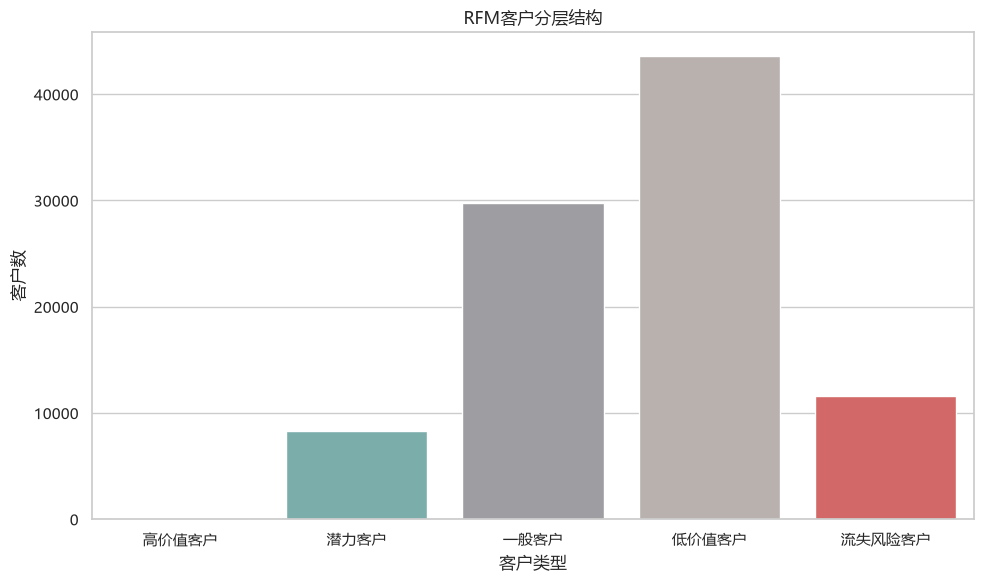

In [11]:
# Windows 环境下设置中文字体，避免中文图表标签乱码
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 固定业务展示顺序，避免按默认字母顺序排列
segment_order = [
    "高价值客户",
    "潜力客户",
    "一般客户",
    "低价值客户",
    "流失风险客户",
]

plot_rfm = (
    rfm_summary
    .set_index("customer_segment")
    .reindex(segment_order)
    .reset_index()
)

# 流失风险客户使用红色强调，便于识别召回优先对象
colors = [
    "#4C78A8",
    "#72B7B2",
    "#9D9DA3",
    "#BAB0AC",
    "#E45756",
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_rfm,
    x="customer_segment",
    y="customer_count",
    hue="customer_segment",
    palette=colors,
    legend=False,
)

plt.title("RFM客户分层结构", pad=16)
plt.xlabel("客户类型")
plt.ylabel("客户数")

# 为标题预留上边距，避免导出图片时被裁切
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    output_dir / "rfm_customer_segments.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


## 10. 分析结论
- SP 州 GMV 显著领先，是最核心的区域市场。
- 月度 GMV 和订单量在 2017 年持续增长，2017 年末达到高位。
- 客户以低价值和一般客户为主；流失风险客户消费能力较高，应优先制定召回策略。

## 复现说明
在项目根目录创建并激活 Python 虚拟环境后，安装依赖：

`pip install pandas matplotlib seaborn jupyter`

然后启动 `jupyter lab`，按顺序运行本 Notebook 的代码单元格。
